In [194]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models


In [195]:

# Параметры задачи
m, n, k = 5, 5, 1  # Размер матрицы m x n с k значениями в каждой ячейке
batch_size = 32
epochs = 40

In [196]:

# Генерация данных
def generate_data(batch_size, m, n, k):
    # Случайные значения от -10 до 10
    X = np.random.uniform(-10, 10, size=(batch_size, m, n, k))
    # Целевые значения: возведение в квадрат
    Y = np.square(X)
    return X, Y

In [197]:


# Создание тренировочных данных
X_train, Y_train = generate_data(batch_size=1000, m=m, n=n, k=k)
X_test, Y_test = generate_data(batch_size=200, m=m, n=n, k=k)


In [198]:

# Определение модели
model = models.Sequential([
    layers.Flatten(input_shape=(m, n, k)),  # Разворачивание матрицы в вектор
    layers.Dense(300, activation='relu'),  # Полносвязный слой
    layers.Dense(100, activation='relu'),   # Полносвязный слой
    layers.Dense(m * n * k, activation='linear'),  # Выходной слой
    layers.Reshape((m, n, k))  # Преобразование в матрицу
])


# Компиляция модели
model.compile(optimizer='adam', loss='mse')

C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [199]:
# Обучение модели с сохранением истории
history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=16,
    validation_data=(X_test, Y_test)
)

Epoch 1/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1551.6240 - val_loss: 897.0024
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 880.5864 - val_loss: 889.0277
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 865.3150 - val_loss: 890.1010
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 859.4473 - val_loss: 889.6147
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 845.9493 - val_loss: 892.1512
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 835.7473 - val_loss: 893.0846
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 816.6470 - val_loss: 895.3391
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 807.3896 - val_loss: 901.1432
Epoch 9/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 800.3216 - val_loss: 905.5078
Epoch 10/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - loss: 784.3629 - val_loss: 911.7599
Epoch 11/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 767.5311 - val_loss: 915.5733
Epoch 12/40
63/63 ━━━━━

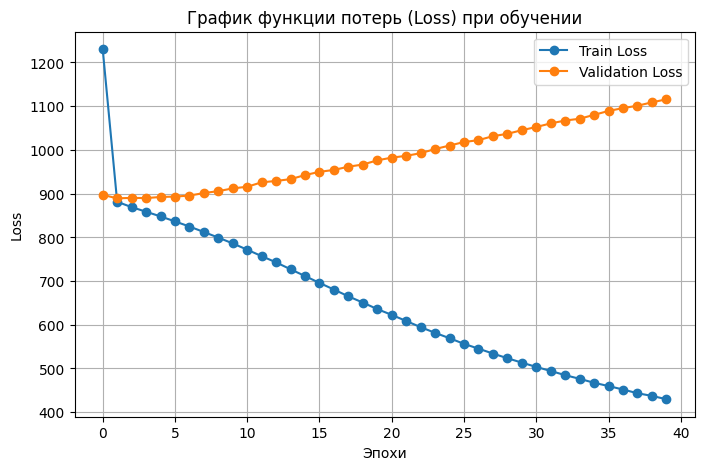

In [200]:
import matplotlib.pyplot as plt

# Построение графика лосс-функции
def plot_loss(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('График функции потерь (Loss) при обучении')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

# Вызов функции для отображения графика
plot_loss(history)

In [201]:


# Тестирование модели
X_sample, Y_sample = generate_data(batch_size=1, m=m, n=n, k=k)
Y_pred = model.predict(X_sample)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [202]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Функция для вычисления метрик
def evaluate_model(y_true, y_pred):
    # Преобразование тензоров в плоские массивы
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Расчёт метрик
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)

    return mse, mae, r2

# Тестирование модели
X_sample, Y_sample = generate_data(batch_size=1, m=m, n=n, k=k)
Y_pred = model.predict(X_sample)

# Расчёт метрик качества
mse, mae, r2 = evaluate_model(Y_sample[0], Y_pred[0])

# Вывод результатов
print("Метрики качества модели:")
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"Средняя абсолютная ошибка (MAE): {mae:.4f}")
print(f"Коэффициент детерминации (R^2): {r2:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Метрики качества модели:
Среднеквадратичная ошибка (MSE): 1202.7585
Средняя абсолютная ошибка (MAE): 27.4296
Коэффициент детерминации (R^2): -0.6563
